# Exploratory Data Analysis of PM2.5 (2020–2023)

This notebook explores temporal trends, seasonal behavior, city-wise variation, and statistical characteristics of PM2.5 concentrations across Canadian cities.
Objective:
- Understand pollution distribution
- Identify seasonal patterns
- Compare cities
- Prepare insights for predictive modeling

## Importing Required Libraries and Loading Dataset

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("../../data/master/PM25_2020 cleaned Master_20_23.csv")
df.head()

,City,Date,PM25,Year,Month,Season
0,Montréal,2020-01-01,4.333333333,2020,1,Winter
1,Montréal,2020-01-02,7.625,2020,1,Winter
2,Montréal,2020-01-03,10.75,2020,1,Winter
3,Montréal,2020-01-04,4.416666667,2020,1,Winter
4,Montréal,2020-01-05,3.833333333,2020,1,Winter


## Dataset Overview

In [5]:
df.shape
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 386424 entries, 0 to 386423
Data columns (total 6 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   City    386424 non-null  object
 1   Date    386424 non-null  object
 2   PM25    386424 non-null  object
 3   Year    386424 non-null  int64 
 4   Month   386424 non-null  int64 
 5   Season  386424 non-null  object
dtypes: int64(2), object(4)
memory usage: 17.7+ MB


City      0
Date      0
PM25      0
Year      0
Month     0
Season    0
dtype: int64

##  Distribution of PM2.5 Concentrations

In [7]:
df["PM25"] = pd.to_numeric(df["PM25"], errors="coerce")
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 386424 entries, 0 to 386423
Data columns (total 6 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   City    386424 non-null  object 
 1   Date    386424 non-null  object 
 2   PM25    327630 non-null  float64
 3   Year    386424 non-null  int64  
 4   Month   386424 non-null  int64  
 5   Season  386424 non-null  object 
dtypes: float64(1), int64(2), object(3)
memory usage: 17.7+ MB


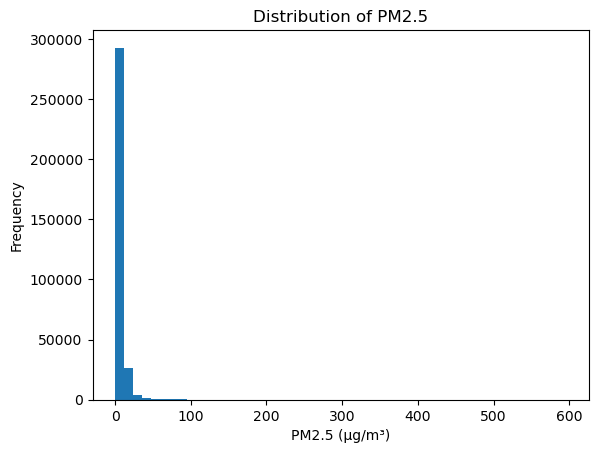

In [8]:
plt.figure()
plt.hist(df["PM25"], bins=50)
plt.title("Distribution of PM2.5")
plt.xlabel("PM2.5 (µg/m³)")
plt.ylabel("Frequency")
plt.show()


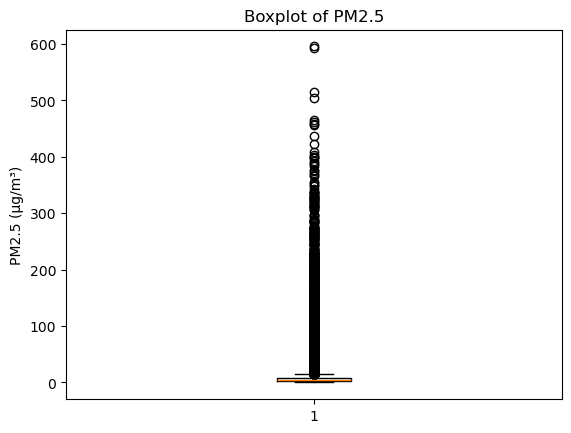

In [9]:
pm = df["PM25"].dropna()

plt.figure()
plt.boxplot(pm, vert=True)
plt.title("Boxplot of PM2.5")
plt.ylabel("PM2.5 (µg/m³)")
plt.savefig("figure_pm25_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()


In [10]:
df["PM25"].isnull().sum()


58794

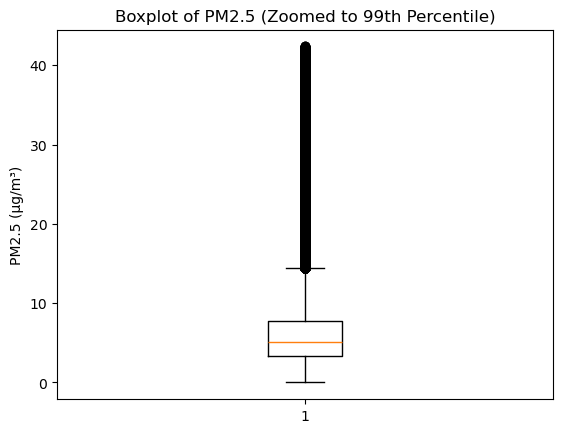

In [11]:
pm = df["PM25"].dropna()
p99 = pm.quantile(0.99)

plt.figure()
plt.boxplot(pm[pm <= p99])
plt.title("Boxplot of PM2.5 (Zoomed to 99th Percentile)")
plt.ylabel("PM2.5 (µg/m³)")
plt.savefig("figure_pm25_boxplot_zoomed.png", dpi=300, bbox_inches="tight")
plt.show()


In [12]:
pm.skew()


14.258149585680307

##  Year-wise Trend of PM2.5 (2020–2023)

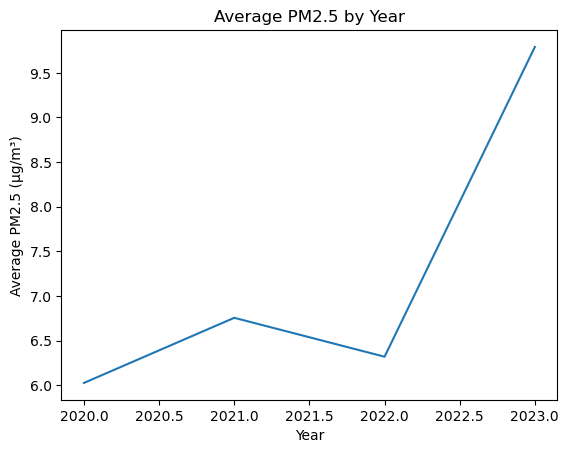

Year
2020    6.025317
2021    6.754914
2022    6.318979
2023    9.789965
Name: PM25, dtype: float64

In [14]:
df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year

yearly_avg = df.groupby("Year")["PM25"].mean()

plt.figure()
plt.plot(yearly_avg.index, yearly_avg.values)
plt.title("Average PM2.5 by Year")
plt.xlabel("Year")
plt.ylabel("Average PM2.5 (µg/m³)")
plt.savefig("pm25_yearly_trend.png", dpi=300, bbox_inches="tight")
plt.show()

yearly_avg

### Interpretation
The annual average PM2.5 levels show a noticeable spike in 2023 compared to previous years. 
This increase may be attributed to widespread wildfire events across Canada during 2023, 
which significantly elevated particulate concentrations.

The relatively lower levels in 2020–2022 suggest more stable pollution conditions prior to the wildfire surge.

## Monthly Average PM2.5
Helps identify recurring seasonal behavior across months.

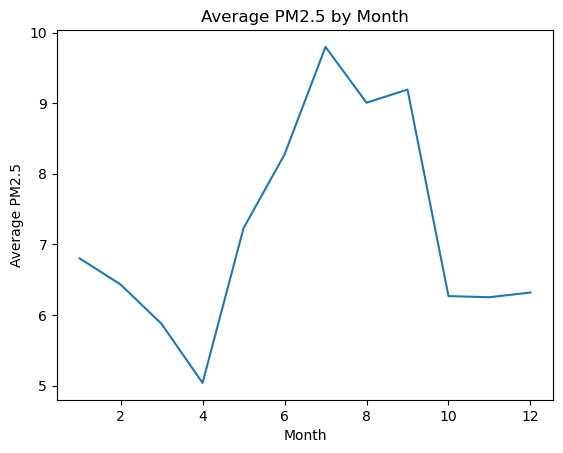

In [17]:
df["Month"] = df["Date"].dt.month

monthly_avg = df.groupby("Month")["PM25"].mean()

plt.figure()
plt.plot(monthly_avg.index, monthly_avg.values)
plt.title("Average PM2.5 by Month")
plt.xlabel("Month")
plt.ylabel("Average PM2.5")
plt.savefig("figure_pm25_monthly_average.png", dpi=300, bbox_inches="tight")
plt.show()


### Interpretation
Monthly averages indicate elevated PM2.5 levels during summer months, particularly June–August. 
This pattern aligns with wildfire seasons in Canada.
Lower concentrations observed in early spring suggest relatively cleaner atmospheric conditions.

## Seasonal Variation in PM2.5
We compare PM2.5 concentrations across seasons to identify recurring pollution cycles.

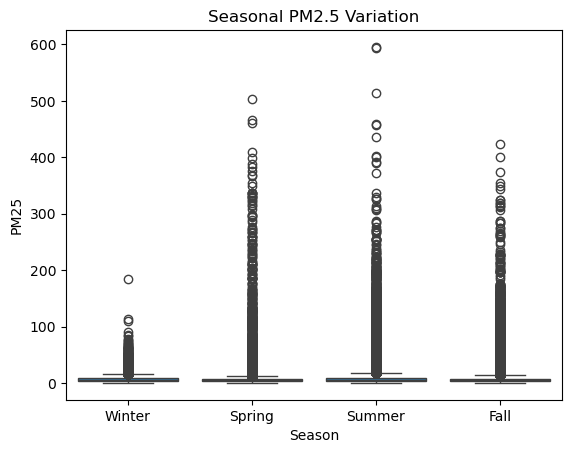

In [20]:
plt.figure()
sns.boxplot(x="Season", y="PM25", data=df)
plt.title("Seasonal PM2.5 Variation")
plt.savefig("figure_pm25_seasonal_variation.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation
Seasonal analysis reveals that PM2.5 concentrations tend to peak during summer, 
likely due to wildfire smoke contributions.

Winter also exhibits moderate pollution levels, potentially influenced by heating emissions 
and stagnant atmospheric conditions.

Spring appears to have comparatively lower median PM2.5 levels.

##  City-wise Average PM2.5 Levels

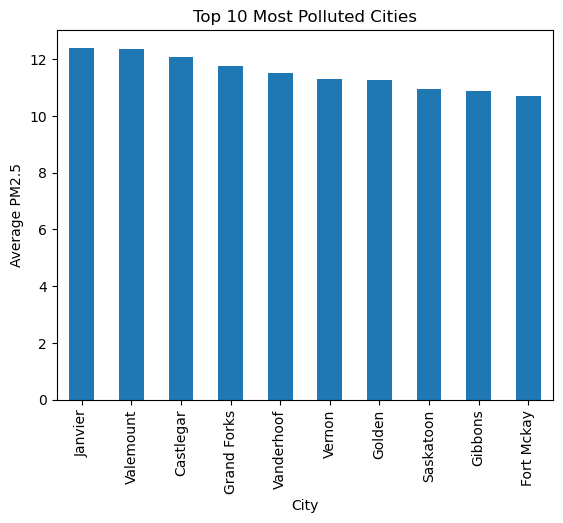

In [23]:
city_avg = df.groupby("City")["PM25"].mean().sort_values(ascending=False)

top10 = city_avg.head(10)

plt.figure()
top10.plot(kind="bar")
plt.title("Top 10 Most Polluted Cities")
plt.ylabel("Average PM2.5")
plt.savefig("figure_pm25_top_cities.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation
City-wise analysis shows that several cities located in western Canada consistently 
record higher average PM2.5 levels.

These regions are more susceptible to wildfire smoke and regional atmospheric transport effects.

## PM2.5 Trends for Top 5 Polluted Cities

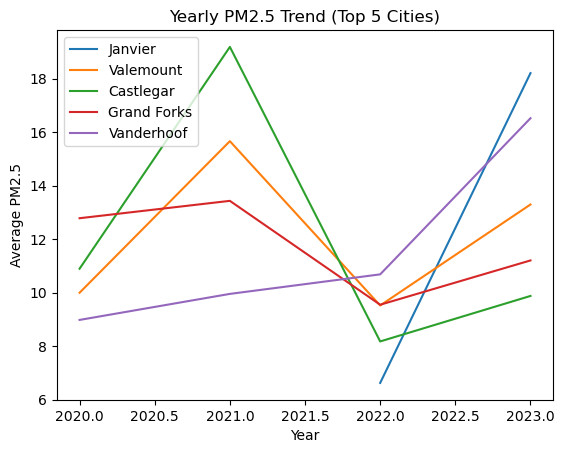

In [26]:
top5_cities = city_avg.head(5).index

plt.figure()

for city in top5_cities:
    city_data = df[df["City"] == city]
    yearly = city_data.groupby("Year")["PM25"].mean()
    plt.plot(yearly.index, yearly.values, label=city)

plt.legend()
plt.title("Yearly PM2.5 Trend (Top 5 Cities)")
plt.xlabel("Year")
plt.ylabel("Average PM2.5")
plt.savefig("figure_pm25_top5_yearly_trend.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation
Trend analysis for the top 5 most polluted cities indicates substantial inter-annual variability.
While some cities experienced peak pollution in 2021, others show a sharp increase in 2023.
This suggests that pollution dynamics are region-specific and influenced by localized environmental events.